# Paired t-Test: Smartphone CPU Usage vs Battery Drain Analysis  <hr style="border:2.5px solid #126782">

<b>Angel Grace R. Macawili</b>
<br>Computer Engineering Technology

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower

**Dataset:** Smartphone Battery Drain Analysis

This dataset contains per-session smartphone usage records including
CPU usage (%) and battery drop per hour (%) measured from the same device
session. Since both measurements come from the same observation, a paired
t-test is used to determine whether CPU usage is significantly higher
than the battery drain rate during smartphone usage sessions.

In [2]:
df = pd.read_csv("dataset/smartphone_battery_drain_dataset.csv",
                 delimiter=",")
df

,App_Running,Screen_On_Time_min,CPU_Usage_%,Battery_Temperature_C,Battery_Drop_Per_Hour,Network_Type,Brightness_Level_%,RAM_Usage_MB,Charging_State,Usage_Mode
0,Facebook,70.779244,55.550655,34.301005,6.020228,5G,57,2941.852469,Charging,Gaming
1,PUBG,90.044282,10.506832,35.607895,13.372379,WiFi,10,1930.581458,Not Charging,Social Media
2,Maps,75.197224,38.529769,43.312775,3.514550,5G,37,2169.828899,Charging,Social Media
3,WhatsApp,114.762495,26.898454,33.795197,6.728475,WiFi,33,2329.369145,Charging,Browsing
4,Facebook,52.214675,36.862349,41.089636,19.134837,5G,25,2175.002939,Charging,Video Streaming
...,...,...,...,...,...,...,...,...,...,...
2498,Instagram,56.488493,24.271686,40.431544,13.258253,WiFi,63,2187.176944,Not Charging,Gaming
2499,WhatsApp,80.865618,33.550557,24.552252,17.555962,5G,17,2653.751518,Charging,Gaming
2500,Chrome,64.043076,48.248489,26.177555,12.686444,WiFi,97,2734.017392,Not Charging,Browsing
2501,PUBG,85.989414,51.872556,29.039868,10.659386,4G,69,2451.633483,Charging,Browsing


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2503 entries, 0 to 2502
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   App_Running            2503 non-null   object 
 1   Screen_On_Time_min     2503 non-null   float64
 2   CPU_Usage_%            2498 non-null   float64
 3   Battery_Temperature_C  2498 non-null   float64
 4   Battery_Drop_Per_Hour  2503 non-null   float64
 5   Network_Type           2503 non-null   object 
 6   Brightness_Level_%     2503 non-null   int64  
 7   RAM_Usage_MB           2503 non-null   float64
 8   Charging_State         2503 non-null   object 
 9   Usage_Mode             2503 non-null   object 
dtypes: float64(5), int64(1), object(4)
memory usage: 195.7+ KB


In [4]:
df = df.rename(columns={
    'CPU_Usage_%'          : 'CPU',
    'Battery_Drop_Per_Hour': 'BatteryDrop'})

df = df.dropna(subset=['CPU', 'BatteryDrop'])
df.reset_index(drop=True, inplace=True)

df

,App_Running,Screen_On_Time_min,CPU,Battery_Temperature_C,BatteryDrop,Network_Type,Brightness_Level_%,RAM_Usage_MB,Charging_State,Usage_Mode
0,Facebook,70.779244,55.550655,34.301005,6.020228,5G,57,2941.852469,Charging,Gaming
1,PUBG,90.044282,10.506832,35.607895,13.372379,WiFi,10,1930.581458,Not Charging,Social Media
2,Maps,75.197224,38.529769,43.312775,3.514550,5G,37,2169.828899,Charging,Social Media
3,WhatsApp,114.762495,26.898454,33.795197,6.728475,WiFi,33,2329.369145,Charging,Browsing
4,Facebook,52.214675,36.862349,41.089636,19.134837,5G,25,2175.002939,Charging,Video Streaming
...,...,...,...,...,...,...,...,...,...,...
2493,Instagram,56.488493,24.271686,40.431544,13.258253,WiFi,63,2187.176944,Not Charging,Gaming
2494,WhatsApp,80.865618,33.550557,24.552252,17.555962,5G,17,2653.751518,Charging,Gaming
2495,Chrome,64.043076,48.248489,26.177555,12.686444,WiFi,97,2734.017392,Not Charging,Browsing
2496,PUBG,85.989414,51.872556,29.039868,10.659386,4G,69,2451.633483,Charging,Browsing


### Summary of Statistics

In [5]:
df[['CPU', 'BatteryDrop']].describe()

,CPU,BatteryDrop
count,2498.000000,2498.000000
mean,34.480392,11.949759
std,15.003228,4.843220
min,1.000000,1.000000
25%,24.231843,8.630984
50%,34.245258,11.849655
75%,44.617992,15.136911
max,83.602087,27.516922


### Boxplot

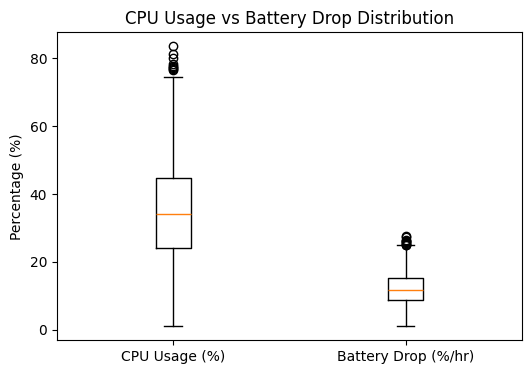

In [6]:
plt.figure(figsize=(6, 4))

plt.boxplot(
    [df['CPU'], df['BatteryDrop']],
    tick_labels=['CPU Usage (%)', 'Battery Drop (%/hr)']
)

plt.title('CPU Usage vs Battery Drop Distribution')
plt.ylabel('Percentage (%)')

plt.show()

In [7]:
# Remove outliers using 3-sigma rule
z_cpu         = stats.zscore(df['CPU'])
z_batterydrop = stats.zscore(df['BatteryDrop'])

df = df[(abs(z_cpu) < 3) & (abs(z_batterydrop) < 3)]
df.reset_index(drop=True, inplace=True)

df

,App_Running,Screen_On_Time_min,CPU,Battery_Temperature_C,BatteryDrop,Network_Type,Brightness_Level_%,RAM_Usage_MB,Charging_State,Usage_Mode
0,Facebook,70.779244,55.550655,34.301005,6.020228,5G,57,2941.852469,Charging,Gaming
1,PUBG,90.044282,10.506832,35.607895,13.372379,WiFi,10,1930.581458,Not Charging,Social Media
2,Maps,75.197224,38.529769,43.312775,3.514550,5G,37,2169.828899,Charging,Social Media
3,WhatsApp,114.762495,26.898454,33.795197,6.728475,WiFi,33,2329.369145,Charging,Browsing
4,Facebook,52.214675,36.862349,41.089636,19.134837,5G,25,2175.002939,Charging,Video Streaming
...,...,...,...,...,...,...,...,...,...,...
2487,Instagram,56.488493,24.271686,40.431544,13.258253,WiFi,63,2187.176944,Not Charging,Gaming
2488,WhatsApp,80.865618,33.550557,24.552252,17.555962,5G,17,2653.751518,Charging,Gaming
2489,Chrome,64.043076,48.248489,26.177555,12.686444,WiFi,97,2734.017392,Not Charging,Browsing
2490,PUBG,85.989414,51.872556,29.039868,10.659386,4G,69,2451.633483,Charging,Browsing


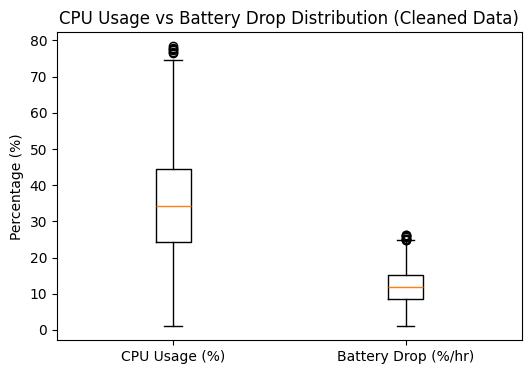

In [8]:
plt.figure(figsize=(6, 4))

plt.boxplot(
    [df['CPU'], df['BatteryDrop']],
    tick_labels=['CPU Usage (%)', 'Battery Drop (%/hr)']
)

plt.title('CPU Usage vs Battery Drop Distribution (Cleaned Data)')
plt.ylabel('Percentage (%)')

plt.show()

### Normality Test

In [9]:
# Shapiro-Wilk normality test
alpha = 0.05

print("CPU Usage:")
w_stat, p_value = stats.shapiro(df['CPU'])
print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < alpha:
    print("Non-normal data")
else:
    print("Normal data")

print("\nBattery Drop Per Hour:")
w_stat, p_value = stats.shapiro(df['BatteryDrop'])
print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < alpha:
    print("Non-normal data")
else:
    print("Normal data")

CPU Usage:
w_stat: 0.9964
P-value: 0.0000
Non-normal data

Battery Drop Per Hour:
w_stat: 0.9966
P-value: 0.0000
Non-normal data


### F-Test

In [10]:
"""
F-Test for equality of variances
--------------------------------
Ho: var_CPU = var_BatteryDrop
Ha: var_CPU != var_BatteryDrop
"""

var_cpu         = df['CPU'].var(ddof=1)
var_batterydrop = df['BatteryDrop'].var(ddof=1)

# F-statistic (larger variance in numerator)
if var_cpu > var_batterydrop:
    f_stat = var_cpu / var_batterydrop
else:
    f_stat = var_batterydrop / var_cpu

print(f'f_stat = {f_stat:.4f}')

# Degrees of Freedom
dof_cpu         = df['CPU'].count() - 1
dof_batterydrop = df['BatteryDrop'].count() - 1

# p-value
p_value = 1 - stats.f.cdf(f_stat, dof_cpu, dof_batterydrop)
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    print('unequal variances')
else:
    print('equal variances')

f_stat = 9.6028
p_value = 0.0000
unequal variances


### Paired t-Test

In [11]:
"""
Paired t-Test
--------------
Ho: mu_CPU <= mu_BatteryDrop
Ha: mu_CPU > mu_BatteryDrop
"""

t_stat, p_value = stats.ttest_rel(df['CPU'], df['BatteryDrop'],
                                   alternative='greater')

print(f't_stat = {t_stat:.4f}')
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    print('CPU usage is significantly higher than the battery drain rate during smartphone sessions.')
else:
    print('There is no significant difference between CPU usage and battery drain rate.')

t_stat = 71.3049
p_value = 0.0000
CPU usage is significantly higher than the battery drain rate during smartphone sessions.


### Power of the Test

In [12]:
# Compute paired differences
diff = df['CPU'] - df['BatteryDrop']

# Cohen's d for paired samples
cohens_d = diff.mean() / diff.std(ddof=1)

# Power analysis
analysis = TTestPower()
power = analysis.power(
    effect_size=cohens_d,
    nobs=len(diff),
    alpha=0.05
)
power_percent = power * 100

print(f"Cohen's d: {cohens_d:.4f}")
print(f"Power of the test: {power_percent:.2f}%")

Cohen's d: 1.4284
Power of the test: 100.00%


## Conclusion

Using a paired t-test to evaluate whether CPU usage is significantly
higher than the battery drain rate during smartphone sessions, the analysis
yielded a t-statistic with a p-value of **< 0.0001**. At the 0.05 significance
level, the null hypothesis is **rejected**. This result indicates that CPU
usage consistently and significantly exceeds the battery drain rate across
smartphone sessions, suggesting that processing demands place a greater
percentage load on the device than the rate at which the battery depletes
per hour.